# INSTALAÇÃO E IMPORTAÇÕES

In [1]:
# DESCRIÇÃO: Esta é a célula de setup. O objetivo dela é garantir que
# o nosso ambiente de programação tenha todas as "ferramentas" (bibliotecas)
# necessárias para executar o projeto do início ao fim.

# --- Instalação das Bibliotecas ---
# A primeira linha usa o comando 'pip' para instalar as bibliotecas Python
# que são a base do nosso projeto. Fazemos isso para garantir que o código
# rode em qualquer máquina, mesmo que ela não tenha essas bibliotecas pré-instaladas.
# --user: Instala as bibliotecas apenas para o usuário atual, evitando conflitos com pacotes do sistema.
!pip install yfinance pandas scikit-learn xgboost ta matplotlib --user

# --- Importações Essenciais ---
# Após garantir que as ferramentas estão instaladas, nós as "importamos"
# para dentro do nosso script, ou seja, as carregamos na memória para poder usá-las.

# Importa bibliotecas para manipulação de dados e tempo.
import yfinance as yf         # Para baixar dados históricos do mercado financeiro (ações, índices, etc.).
import pandas as pd           # A principal ferramenta para trabalhar com tabelas de dados (DataFrames). É o "Excel" do Python.
from datetime import datetime, timedelta # Para trabalhar com datas e períodos de tempo.
import numpy as np            # Usada para cálculos numéricos eficientes, especialmente com grandes volumes de dados.
import os                     # Para interagir com o sistema operacional, como salvar arquivos em pastas.

# Importa bibliotecas para visualização de dados.
import matplotlib.pyplot as plt # A principal biblioteca para criar gráficos de todos os tipos.
import matplotlib.ticker as mticker # Usada para formatações avançadas nos eixos dos gráficos.

# Importa as ferramentas de Machine Learning (IA).
from sklearn.preprocessing import StandardScaler      # Para normalizar nossos dados, colocando todos na mesma escala.
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV # Ferramentas cruciais para treinar e otimizar nosso modelo de forma correta para séries temporais.
from sklearn.metrics import classification_report   # Para avaliar a performance do nosso modelo (precisão, recall, etc.).
import xgboost as xgb                               # A biblioteca do nosso modelo de IA (XGBoost), famoso por sua alta performance.

# Importa a biblioteca para Análise Técnica.
import ta                     # Uma biblioteca fantástica que calcula dezenas de indicadores técnicos (RSI, MACD, etc.) automaticamente.

# CÉLULA 2: PAINEL DE CONTROLE FINAL E ESTRATÉGICO

In [2]:
# DESCRIÇÃO: Esta célula é o "cérebro" estratégico do nosso sistema.
# Aqui, definimos todas as variáveis e configurações que o motor de backtesting
# irá usar. Alterar valores aqui nos permite testar diferentes hipóteses
# sem precisar tocar na lógica principal do código.

# --- Configuração de Realismo Financeiro ---
# Define um custo de transação simulado para cada operação de compra.
# Isso torna nosso backtest mais realista, pois em uma corretora real,
# toda compra e venda tem um pequeno custo (taxas, emolumentos).
# O valor 0.001 equivale a 0.1% do valor da operação.
CUSTO_TRANSACAO_PCT = 0.001

# --- ESTRATÉGIA DE MODELOS: GERAL VS. ESPECIALISTA ---
# DESCRIÇÃO: Aqui definimos o "time de especialistas" da nossa IA.
# A ideia é que, em vez de um modelo genérico, cada ativo seja analisado
# por um modelo treinado com os fatores que se provaram mais preditivos
# para ele. Esta abordagem reflete a conclusão de nossa pesquisa: diferentes
# ativos reagem a diferentes estímulos em diferentes cenários.
#
# INSTRUÇÃO PARA A EQUIPE: O processo é um ciclo de melhoria contínua:
# 1. Rode o sistema com um conjunto amplo de fatores para todos os ativos.
# 2. Analise os gráficos de "Importância das Features" gerados na Célula 4.
# 3. Volte para este dicionário e remova/adicione fatores para otimizar a
#    performance de cada modelo especialista.
#
#    NOTA ATUAL: Mantivemos a configuração que inclui o fator ESG para todos
#    os ativos, pois o objetivo principal no momento é testar a hipótese
#    geral do poder preditivo deste fator. Após esta fase de teste, poderemos
#    refinar e remover o fator ESG dos modelos em que ele não se provar útil.
CONFIGURACAO_ESPECIALIZADA_ATIVOS = {
    # VALE3: Modelo usa fatores de commodities (Minério de Ferro, Petróleo),
    # mercado chinês (MCHI), câmbio (BRL=X) e o nosso fator ESG.
    "VALE3.SA": {
        "fatores": ['SI=F', 'MCHI', 'BRL=X', 'CL=F', 'ESGB11.SA'],
        "nomes": ['Preco_Minerio_Ferro', 'ETF_China', 'Taxa_Cambio_USD_BRL', 'Preco_Petroleo', 'ETF_ESG_Brasil']
    },
    # ITUB4 (e outros bancos/empresas domésticas): Modelo usa fatores do mercado
    # brasileiro (Ibovespa, ETF Brasil), câmbio e o fator ESG.
    "ITUB4.SA": {
        "fatores": ['^BVSP', 'EWZ', 'BRL=X', 'ESGB11.SA'],
        "nomes": ['Indice_Ibovespa', 'ETF_Brasil', 'Taxa_Cambio_USD_BRL', 'ETF_ESG_Brasil']
    },
    "LREN3.SA": {
        "fatores": ['^BVSP', 'EWZ', 'BRL=X', 'ESGB11.SA'],
        "nomes": ['Indice_Ibovespa', 'ETF_Brasil', 'Taxa_Cambio_USD_BRL', 'ETF_ESG_Brasil']
    },
    "ELET3.SA": {
        "fatores": ['^BVSP', 'EWZ', 'BRL=X', 'ESGB11.SA'],
        "nomes": ['Indice_Ibovespa', 'ETF_Brasil', 'Taxa_Cambio_USD_BRL', 'ETF_ESG_Brasil']
    },
    "RADL3.SA": {
        "fatores": ['^BVSP', 'EWZ', 'BRL=X', 'ESGB11.SA'],
        "nomes": ['Indice_Ibovespa', 'ETF_Brasil', 'Taxa_Cambio_USD_BRL', 'ETF_ESG_Brasil']
    }
}

# --- Cenários de Tempo e Lista de Ativos ---
# DESCRIÇÃO: Aqui definimos os "campos de prova" para a nossa IA.
# Cada cenário representa um período histórico com características de mercado distintas.
# O cenário "Crise COVID-19" foi removido porque nosso fator ESG (ESGB11.SA)
# ainda não tinha dados históricos para aquele período. Focamos nos cenários
# onde podemos testar a estratégia completa e de forma consistente.
CENARIOS_DE_TESTE = {
    # Cenário que cobre a recuperação pós-pandemia, mas que, na prática, foi um
    # período de baixa/lateral para a bolsa brasileira devido a riscos fiscais e alta de juros no Brasil.
    "Mercado de Alta Pós-Pandemia": {
        "data_inicio_geral": datetime(2019, 1, 1),
        "data_fim_treino": datetime(2020, 12, 31),
        "data_fim_validacao": datetime(2021, 6, 30),
        "data_fim_teste": datetime(2021, 12, 31),
    },
    # Cenário que representa um ambiente econômico de alta na taxa de juros global e incerteza,
    # mas em que o Brasil se destacou por suas commodities e por ter iniciado o ciclo de alta de juros antes.
    "Mercado Desafiador (Juros Altos)": {
        "data_inicio_geral": datetime(2020, 1, 1),
        "data_fim_treino": datetime(2021, 12, 31),
        "data_fim_validacao": datetime(2022, 6, 30),
        "data_fim_teste": datetime(2022, 12, 31),
    },
}

# Define a lista de ativos que compõem o nosso universo de investimento.
LISTA_DE_ATIVOS = ['VALE3.SA', 'ITUB4.SA', 'LREN3.SA', 'ELET3.SA', 'RADL3.SA']

# CÉLULA 3: FUNÇÕES DO SISTEMA

In [3]:
# DESCRIÇÃO: Esta célula contém todas as funções que realizam o trabalho pesado.
# Cada função é como um operário especializado em uma tarefa: um coleta os dados,
# outro cria os indicadores, um treina a IA, e assim por diante. Manter a lógica
# organizada em funções torna o código mais limpo, fácil de entender e de dar manutenção.

def coletar_dados(ticker, fatores, nomes_fatores, start, end):
    """
    Função 1: O Coletor de Dados.
    OBJETIVO: Baixar da internet todos os dados históricos que precisamos.
    - ticker: O código da ação principal (ex: "VALE3.SA").
    - fatores: Uma lista de outros códigos (índices, moedas) que usaremos para prever o ticker principal.
    - start, end: O período de tempo desejado.
    """
    print(f"--- Coletando dados para {ticker} de {start.date()} a {end.date()} ---")
    # Junta o ticker principal e seus fatores em uma única lista para um download mais eficiente.
    todos_tickers = list(set([ticker] + fatores))
    
    # Bloco 'try-except': Uma medida de segurança. Tenta baixar os dados. Se a internet
    # falhar ou um ticker não for encontrado, ele captura o erro, avisa, e continua
    # a execução sem quebrar o programa inteiro.
    try:
        dados = yf.download(todos_tickers, start=start, end=end, progress=False, auto_adjust=True)
    except Exception as e:
        print(f"ERRO CRÍTICO ao baixar dados para {ticker}: {e}")
        return pd.DataFrame() # Retorna uma tabela vazia se falhar.

    # Validações para garantir que os dados do ativo principal foram baixados corretamente.
    if dados.empty or ticker not in dados['Close'].columns or dados['Close'][ticker].isnull().all():
        print(f"Erro: Falha ao baixar dados para o ticker principal {ticker}.")
        return pd.DataFrame()
        
    # Organiza os dados baixados em uma nova tabela (DataFrame) limpa.
    df = pd.DataFrame(index=dados.index)
    df['Preco_Fechamento'] = dados['Close'][ticker]
    df['Volume'] = dados['Volume'][ticker]
    
    # Adiciona os dados de cada fator (ex: Ibovespa, Dólar) à nossa tabela principal.
    for fator, nome in zip(fatores, nomes_fatores):
        if fator in dados['Close'].columns and not dados['Close'][fator].isnull().all(): 
            df[nome] = dados['Close'][fator]
        else: 
            # Se um fator específico falhar, o código avisa e preenche com "NaN" (Not a Number).
            print(f"Aviso: Não foi possível baixar ou dados vazios para o fator '{nome}' ({fator}).")
            df[nome] = np.nan
            
    return df

def engenharia_fatores(df):
    """
    Função 2: O Engenheiro de Features.
    OBJETIVO: Transformar dados brutos (preço, volume) em informações inteligentes (features)
    que o modelo de IA possa usar para aprender padrões.
    """
    print("--- Realizando engenharia de fatores ---")
    # 'ffill': Preenche "buracos" nos dados (ex: feriados) repetindo o valor do dia anterior.
    df.ffill(inplace=True)
    if df.empty: return df

    # --- Criação dos Indicadores (Features) ---
    # Retorno_1d: A variação percentual do preço de um dia para o outro. É a base de tudo.
    df['Retorno_1d'] = df['Preco_Fechamento'].pct_change()
    # Momentum_5d: Mede a "força" do movimento de preço na última semana (5 dias).
    df['Momentum_5d'] = df['Preco_Fechamento'].pct_change(5)
    # Volatilidade_10d: Mede o "grau de agitação" dos preços nas últimas duas semanas.
    df['Volatilidade_10d'] = df['Retorno_1d'].rolling(window=10).std()
    # RSI_14d: Índice de Força Relativa. Um indicador clássico que mede se um ativo está "caro" (sobrecomprado) ou "barato" (sobrevendido).
    df['RSI_14d'] = ta.momentum.RSIIndicator(close=df['Preco_Fechamento'], window=14).rsi()
    # SMA_10_50_Ratio: A razão entre a média de preços dos últimos 10 dias e a dos últimos 50. Ajuda a identificar tendências.
    df['SMA_10_50_Ratio'] = ta.trend.SMAIndicator(df['Preco_Fechamento'], window=10).sma_indicator() / \
                           ta.trend.SMAIndicator(df['Preco_Fechamento'], window=50).sma_indicator()
    
    # MACD_diff: Um indicador de tendência que mostra a relação entre duas médias móveis de preços.
    df['MACD_diff'] = ta.trend.MACD(df['Preco_Fechamento']).macd_diff()
    # BB_Width: Largura das Bandas de Bollinger. Mede a volatilidade. Bandas estreitas podem indicar um grande movimento de preço iminente.
    df['BB_Width'] = ta.volatility.BollingerBands(df['Preco_Fechamento']).bollinger_wband()
    
    # 'dropna': Remove as primeiras linhas que ficam com valores nulos após os cálculos de médias e indicadores.
    df.dropna(inplace=True)
    
    if df.empty:
        print("ERRO CRÍTICO: DataFrame ficou vazio após engenharia de fatores.")
    return df

def criar_alvo_e_retorno_futuro(df):
    """
    Função 3: O Criador de Alvo (Anti-Vazamento de Dados).
    OBJETIVO: Criar a coluna que a IA tentará prever (o "alvo") de forma segura.
    Esta é uma das funções MAIS IMPORTANTES para a validade do projeto.
    """
    if df.empty:
        return df
    # 'Retorno_Futuro': Criamos uma coluna com o retorno do DIA SEGUINTE. É esta a informação que queremos prever.
    df['Retorno_Futuro'] = df['Retorno_1d'].shift(-1)
    
    # 'Target_Compra': A variável alvo. É 1 se o retorno do dia seguinte for positivo (maior que 0.2%), e 0 caso contrário.
    # É a resposta que a IA precisa aprender a prever: "Devo comprar (1) ou não (0)?".
    df['Target_Compra'] = (df['Retorno_Futuro'] > 0.002).astype(int)
    
    # 'dropna': A última linha do dataframe terá um 'Retorno_Futuro' vazio (NaN), então a removemos.
    # Esta função é chamada DEPOIS de separar os dados em treino/validação/teste para
    # garantir que o modelo nunca treine com informações do futuro (evitando o "lookahead bias").
    df.dropna(inplace=True)
    return df

def plotar_importancia_features(modelo, features, ticker, cenario):
    """
    Função 4: O Analista de IA.
    OBJETIVO: Mostrar o "cérebro" do nosso modelo. Ele plota um gráfico que revela
    quais features (indicadores) a IA considerou mais importantes para tomar suas decisões.
    """
    if hasattr(modelo, 'feature_importances_'):
        importances = modelo.feature_importances_
        feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
        # Ordena as features da mais para a menos importante e pega as 10 principais.
        feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

        plt.figure(figsize=(10, 6))
        plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
        plt.xlabel('Importância (F-score)')
        plt.ylabel('Feature')
        plt.title(f'Importância das Features para {ticker} no Cenário "{cenario}"')
        plt.gca().invert_yaxis() # Inverte o eixo para mostrar a mais importante no topo.
        plt.tight_layout()
        plt.show()

def otimizar_modelo_xgb(df_treino, features, target, ticker, cenario):
    """
    Função 5: O Treinador da IA.
    OBJETIVO: Treinar o modelo XGBoost e encontrar a melhor configuração de
    parâmetros (hiperparâmetros) para ele.
    """
    print("--- Otimizando hiperparâmetros do XGBoost... ---")
    X_treino = df_treino[features] # As 'perguntas' (features) que faremos ao modelo.
    y_treino = df_treino[target]   # As 'respostas' (alvo) que ele deve aprender.
    if X_treino.empty: 
        print("ERRO: Conjunto de treino vazio.")
        return None, None

    # 'StandardScaler': Normaliza os dados. Coloca todas as features na mesma escala
    # (ex: de -1 a 1), o que ajuda o modelo a aprender de forma mais eficiente.
    scaler = StandardScaler()
    X_treino_scaled = scaler.fit_transform(X_treino)
    
    # 'TimeSeriesSplit': Define a estratégia correta de validação para dados de tempo.
    # Garante que o modelo sempre treine com dados do passado para prever o futuro.
    tscv = TimeSeriesSplit(n_splits=3)
    
    # 'param_grid': Define o "cardápio" de configurações que queremos testar.
    # O GridSearchCV irá testar todas as 108 combinações possíveis.
    param_grid = {
        "max_depth": [3, 5, 7],             # Profundidade das "árvores de decisão" do modelo.
        "n_estimators": [100, 200, 300],    # Número de árvores.
        "learning_rate": [0.01, 0.05, 0.1], # A "velocidade" de aprendizado do modelo.
        "subsample": [0.7, 1.0],            # Fração de dados a serem usados por árvore.
        "colsample_bytree": [0.7, 1.0]      # Fração de features a serem usadas por árvore.
    }
    
    # Cria o modelo XGBoost com configurações base.
    xgb_model = xgb.XGBClassifier(objective='binary:logistic', use_label_encoder=False, verbosity=0, eval_metric='logloss', random_state=42)
    
    print(f"Iniciando GridSearchCV com {108} combinações. Isso pode demorar...")
    
    # 'GridSearchCV': O "super-treinador". Ele testa cada combinação de parâmetros do 'param_grid'
    # usando a validação 'tscv' e descobre qual delas gera o melhor modelo, otimizando pelo 'f1-score'.
    gsearch = GridSearchCV(xgb_model, param_grid, cv=tscv, scoring='f1', n_jobs=-1)
    gsearch.fit(X_treino_scaled, y_treino)
    
    print(f"Melhores parâmetros encontrados: {gsearch.best_params_}")
    
    # Após encontrar o melhor modelo, chamamos a função para analisar o que ele aprendeu.
    plotar_importancia_features(gsearch.best_estimator_, features, ticker, cenario)
    
    # Retorna o melhor modelo encontrado e o normalizador de dados.
    return gsearch.best_estimator_, scaler

def otimizar_limiar(modelo, scaler, df_validacao, features):
    """
    Função 6: O Estrategista.
    OBJETIVO: Definir o "gatilho" de compra. A IA não diz "sim" ou "não", mas sim uma
    probabilidade (ex: "75% de chance de subir"). Esta função testa vários níveis de
    confiança (limiares) e descobre qual deles teria sido mais lucrativo no
    período de validação.
    """
    print("--- Otimizando o limiar de decisão... ---")
    X_validacao = df_validacao[features]
    if X_validacao.empty:
        print("AVISO: Conjunto de validação vazio. Usando limiar padrão 0.50.")
        return 0.5 
        
    X_validacao_scaled = scaler.transform(X_validacao)
    # Pega as probabilidades de compra (classe 1) geradas pelo modelo.
    probabilidades = modelo.predict_proba(X_validacao_scaled)[:, 1]
    
    melhor_lucro = -np.inf
    melhor_limiar = 0.5
    # Testa limiares de 0.40 (mais agressivo) até 0.60 (mais conservador).
    for limiar in np.arange(0.40, 0.61, 0.01):
        sinais = (probabilidades > limiar).astype(int)
        retorno_estrategia = df_validacao['Retorno_Futuro'] * sinais
        lucro_final = 1000 * (1 + retorno_estrategia).cumprod().iloc[-1] - 1000
        # Se o lucro com o limiar testado for o maior até agora, ele é guardado.
        if lucro_final > melhor_lucro:
            melhor_lucro = lucro_final
            melhor_limiar = limiar
            
    print(f"Melhor limiar encontrado: {melhor_limiar:.2f}")
    return melhor_limiar

def executar_backtest(modelo, scaler, df_teste, features, limiar, ticker, cenario, custo_transacao_pct):
    """
    Função 7: O Simulador (Backtester).
    OBJETIVO: Executar a simulação final em dados que o modelo NUNCA VIU (o período de teste)
    e salvar a probabilidade (confiança) da IA para ser usada na simulação de portfólio.
    """
    print("--- Executando backtest final ---")
    if df_teste.empty:
        print("ERRO: Conjunto de teste vazio. Backtest cancelado.")
        return None

    # Gera as probabilidades brutas (a "confiança" da IA) para cada dia.
    probabilidades = modelo.predict_proba(scaler.transform(df_teste[features]))[:, 1]
    # Salva essa confiança em uma nova coluna. Será crucial para a Célula 7.
    df_teste['Probabilidade_IA'] = probabilidades
    
    # Converte a confiança em um sinal binário (0 ou 1) usando o limiar otimizado.
    sinais = (probabilidades > limiar).astype(int)
    df_teste['Sinal_IA'] = sinais
    
    # Calcula o custo de transação apenas nos dias em que uma nova compra é efetuada.
    sinais_de_compra = (df_teste['Sinal_IA'] == 1) & (df_teste['Sinal_IA'].shift(1).fillna(0) == 0)
    custos = sinais_de_compra * custo_transacao_pct
    
    capital_inicial = 1000
    # Calcula o retorno diário da nossa estratégia (retorno do ativo nos dias de compra, menos os custos).
    df_teste['Retorno_Estrategia'] = (df_teste['Retorno_Futuro'] * df_teste['Sinal_IA']) - custos
    # Calcula a curva de crescimento do capital para a nossa estratégia.
    df_teste['Capital_Estrategia'] = capital_inicial * (1 + df_teste['Retorno_Estrategia']).cumprod()
    # Calcula a curva de crescimento do capital para a estratégia benchmark (comprar e segurar).
    df_teste['Capital_Benchmark'] = capital_inicial * (1 + df_teste['Retorno_Futuro']).cumprod()
    
    lucro_ia = df_teste['Capital_Estrategia'].iloc[-1] - capital_inicial
    lucro_benchmark = df_teste['Capital_Benchmark'].iloc[-1] - capital_inicial
    
    # Imprime um resumo claro dos resultados financeiros.
    print("\n" + "-"*40)
    print(f"RESULTADO FINANCEIRO: {ticker} | Cenário: {cenario}")
    print(f"Custo por transação simulado: {custo_transacao_pct*100:.2f}%")
    print(f"Período de Teste: {df_teste.index.min().date()} a {df_teste.index.max().date()}")
    print(f"Lucro/Perda da Estratégia IA: R$ {lucro_ia:.2f}")
    print(f"Lucro/Perda do Benchmark (Buy & Hold): R$ {lucro_benchmark:.2f}")
    print("-"*40)

    # Plota o gráfico de desempenho para análise visual.
    plt.figure(figsize=(14, 7))
    plt.plot(df_teste.index, df_teste['Capital_Estrategia'], label='Estratégia IA (com custos)')
    plt.plot(df_teste.index, df_teste['Capital_Benchmark'], label='Benchmark (Buy & Hold)', linestyle='--')
    plt.title(f'Desempenho para {ticker} no Cenário "{cenario}"')
    plt.xlabel('Data')
    plt.ylabel('Capital Acumulado (R$)')
    plt.legend()
    plt.grid(True)
    nome_arquivo = f"resultado_{ticker}_{cenario.replace(' ', '_')}.png"
    
    try:
        plt.savefig(nome_arquivo)
        print(f"\nGráfico salvo como '{nome_arquivo}'")
    except Exception as e:
        print(f"\nERRO ao salvar o gráfico '{nome_arquivo}': {e}")
    plt.show()
    return df_teste

def avaliar_performance_modelo(df_resultado, target):
    """
    Função 8: O Avaliador de Performance.
    OBJETIVO: Medir a qualidade das PREVISÕES do modelo, independentemente do resultado
    financeiro. Ele nos diz o quão bom o modelo é em acertar se o dia seguinte
    será de alta ou de baixa.
    """
    if df_resultado is None or df_resultado.empty:
        return
    y_true = df_resultado[target] # As respostas corretas.
    y_pred = df_resultado['Sinal_IA'] # As previsões do nosso modelo.
    
    print("\n" + "-"*40)
    print(f"MÉTRICAS DE CLASSIFICAÇÃO")
    # Gera um relatório completo com as principais métricas:
    # - precision: De todas as vezes que o modelo disse "Compra", quantas ele acertou?
    # - recall: De todas as oportunidades de compra que realmente existiram, quantas o modelo conseguiu identificar?
    # - f1-score: Uma média harmônica entre precision e recall, bom para ter uma visão geral.
    report = classification_report(y_true, y_pred, target_names=['Não Compra (0)', 'Compra (1)'], zero_division=0)
    print(report)
    print("-"*40)

# CÉLULA 4: EXECUÇÃO PRINCIPAL (ORQUESTRADOR)


== EXECUTANDO CENÁRIO: 'Mercado de Alta Pós-Pandemia' PARA O ATIVO: VALE3.SA ===
--- Coletando dados para VALE3.SA de 2019-01-01 a 2021-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost... ---
Iniciando GridSearchCV com 108 combinações. Isso pode demorar...
Melhores parâmetros encontrados: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}


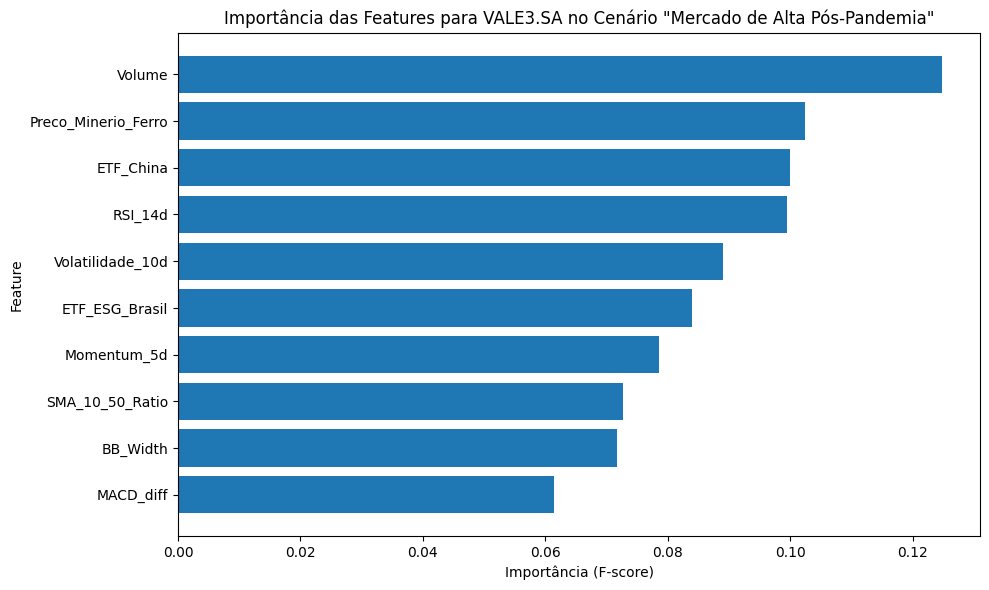

--- Otimizando o limiar de decisão... ---
Melhor limiar encontrado: 0.40
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: VALE3.SA | Cenário: Mercado de Alta Pós-Pandemia
Custo por transação simulado: 0.10%
Período de Teste: 2021-07-01 a 2021-12-29
Lucro/Perda da Estratégia IA: R$ -166.81
Lucro/Perda do Benchmark (Buy & Hold): R$ -226.65
----------------------------------------

Gráfico salvo como 'resultado_VALE3.SA_Mercado_de_Alta_Pós-Pandemia.png'


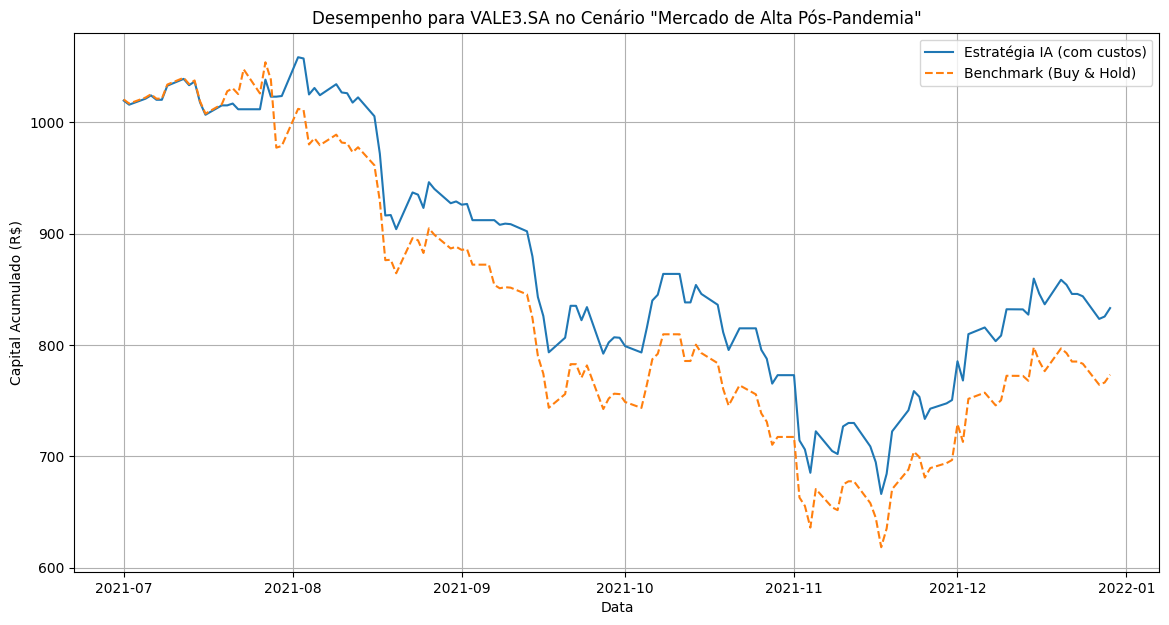


== EXECUTANDO CENÁRIO: 'Mercado de Alta Pós-Pandemia' PARA O ATIVO: ITUB4.SA ===
--- Coletando dados para ITUB4.SA de 2019-01-01 a 2021-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost... ---
Iniciando GridSearchCV com 108 combinações. Isso pode demorar...
Melhores parâmetros encontrados: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}


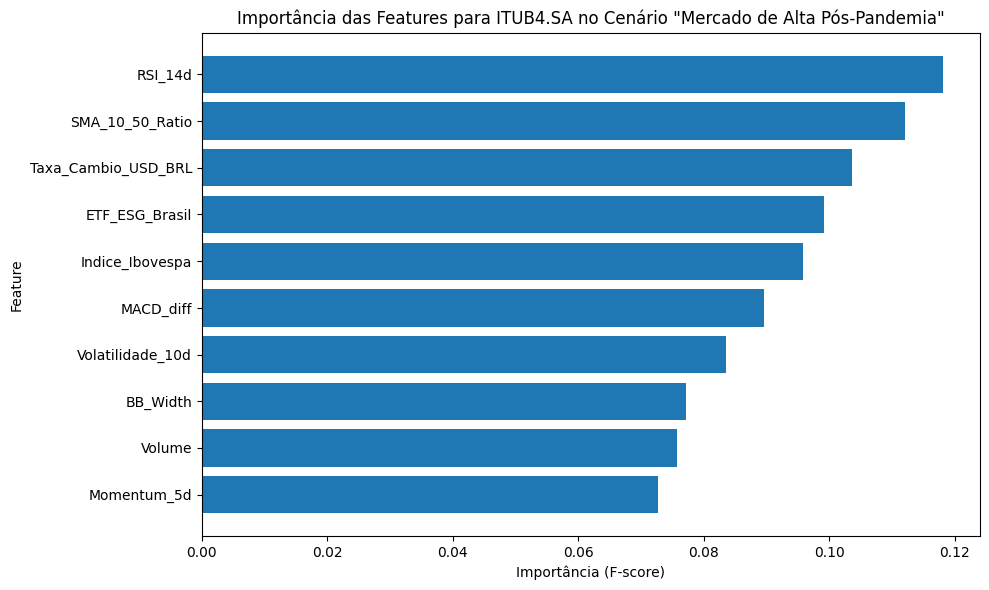

--- Otimizando o limiar de decisão... ---
Melhor limiar encontrado: 0.44
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: ITUB4.SA | Cenário: Mercado de Alta Pós-Pandemia
Custo por transação simulado: 0.10%
Período de Teste: 2021-07-01 a 2021-12-29
Lucro/Perda da Estratégia IA: R$ 103.59
Lucro/Perda do Benchmark (Buy & Hold): R$ -281.29
----------------------------------------

Gráfico salvo como 'resultado_ITUB4.SA_Mercado_de_Alta_Pós-Pandemia.png'


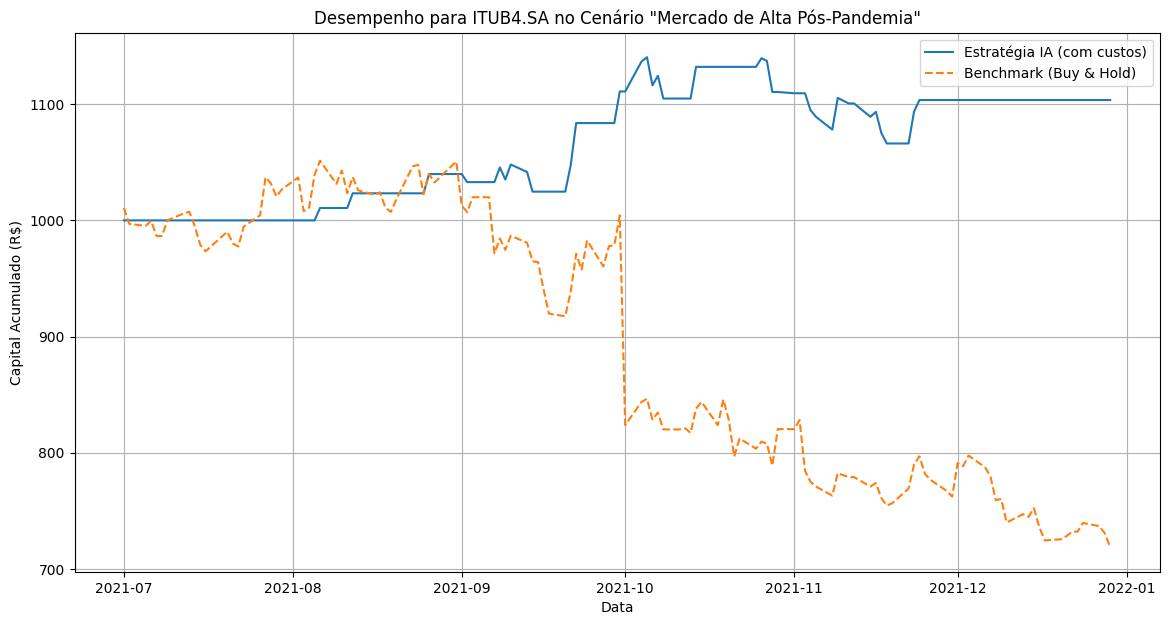


== EXECUTANDO CENÁRIO: 'Mercado de Alta Pós-Pandemia' PARA O ATIVO: LREN3.SA ===
--- Coletando dados para LREN3.SA de 2019-01-01 a 2021-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost... ---
Iniciando GridSearchCV com 108 combinações. Isso pode demorar...
Melhores parâmetros encontrados: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}


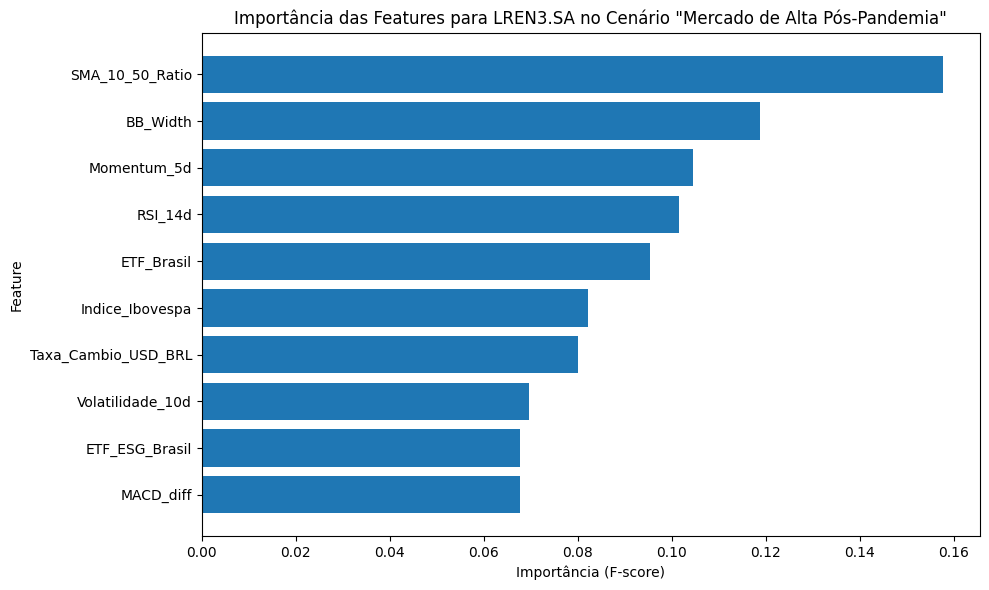

--- Otimizando o limiar de decisão... ---
Melhor limiar encontrado: 0.46
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: LREN3.SA | Cenário: Mercado de Alta Pós-Pandemia
Custo por transação simulado: 0.10%
Período de Teste: 2021-07-01 a 2021-12-29
Lucro/Perda da Estratégia IA: R$ -182.91
Lucro/Perda do Benchmark (Buy & Hold): R$ -366.80
----------------------------------------

Gráfico salvo como 'resultado_LREN3.SA_Mercado_de_Alta_Pós-Pandemia.png'


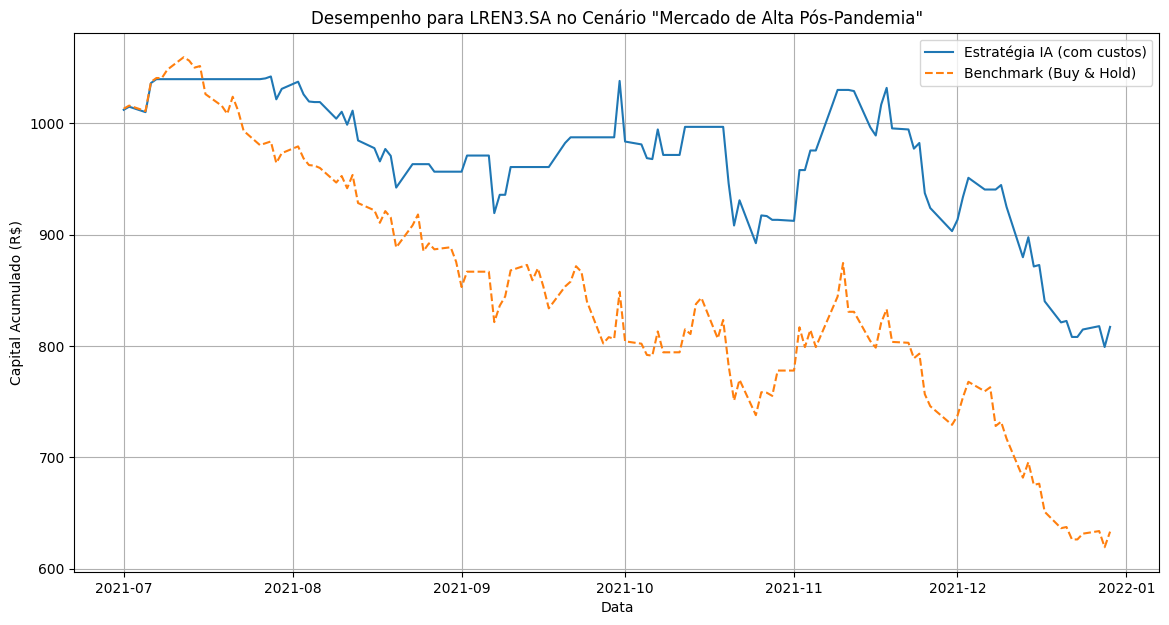


== EXECUTANDO CENÁRIO: 'Mercado de Alta Pós-Pandemia' PARA O ATIVO: ELET3.SA ===
--- Coletando dados para ELET3.SA de 2019-01-01 a 2021-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost... ---
Iniciando GridSearchCV com 108 combinações. Isso pode demorar...
Melhores parâmetros encontrados: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}


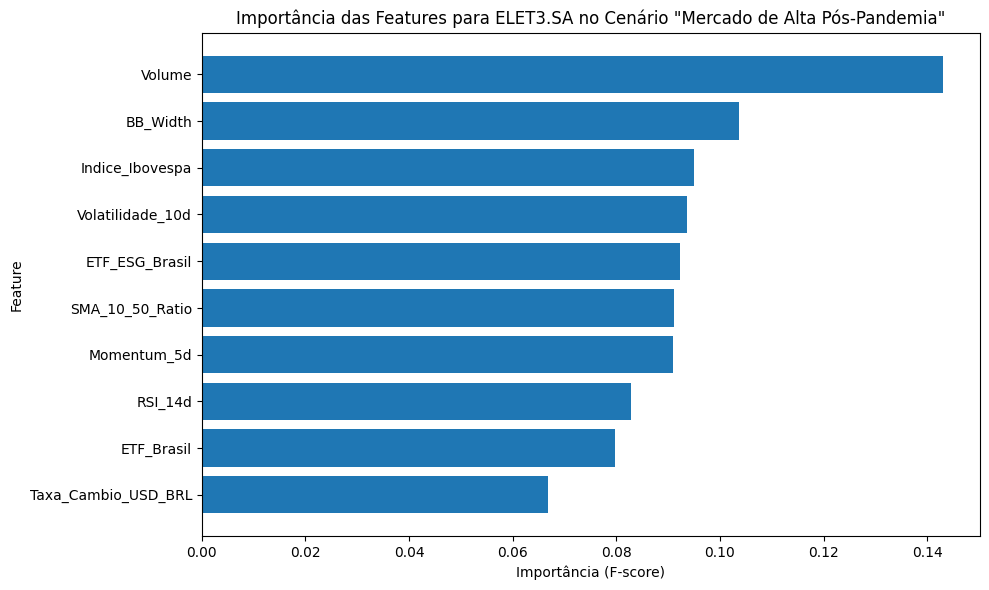

--- Otimizando o limiar de decisão... ---
Melhor limiar encontrado: 0.46
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: ELET3.SA | Cenário: Mercado de Alta Pós-Pandemia
Custo por transação simulado: 0.10%
Período de Teste: 2021-07-01 a 2021-12-29
Lucro/Perda da Estratégia IA: R$ -269.89
Lucro/Perda do Benchmark (Buy & Hold): R$ -230.54
----------------------------------------

Gráfico salvo como 'resultado_ELET3.SA_Mercado_de_Alta_Pós-Pandemia.png'


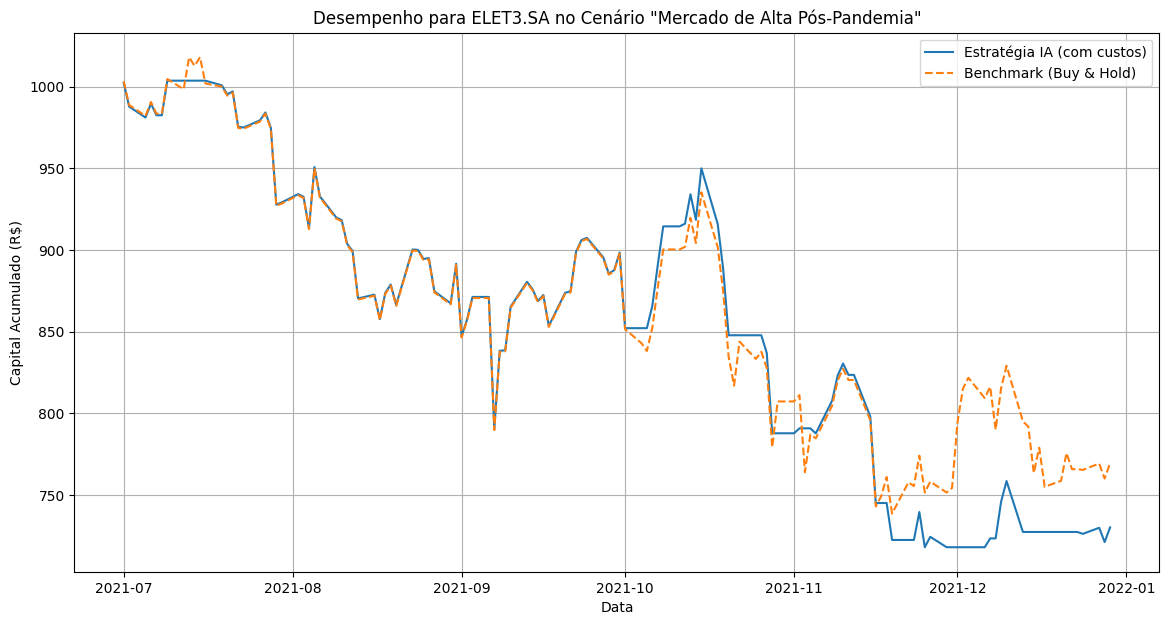


== EXECUTANDO CENÁRIO: 'Mercado de Alta Pós-Pandemia' PARA O ATIVO: RADL3.SA ===
--- Coletando dados para RADL3.SA de 2019-01-01 a 2021-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost... ---
Iniciando GridSearchCV com 108 combinações. Isso pode demorar...
Melhores parâmetros encontrados: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}


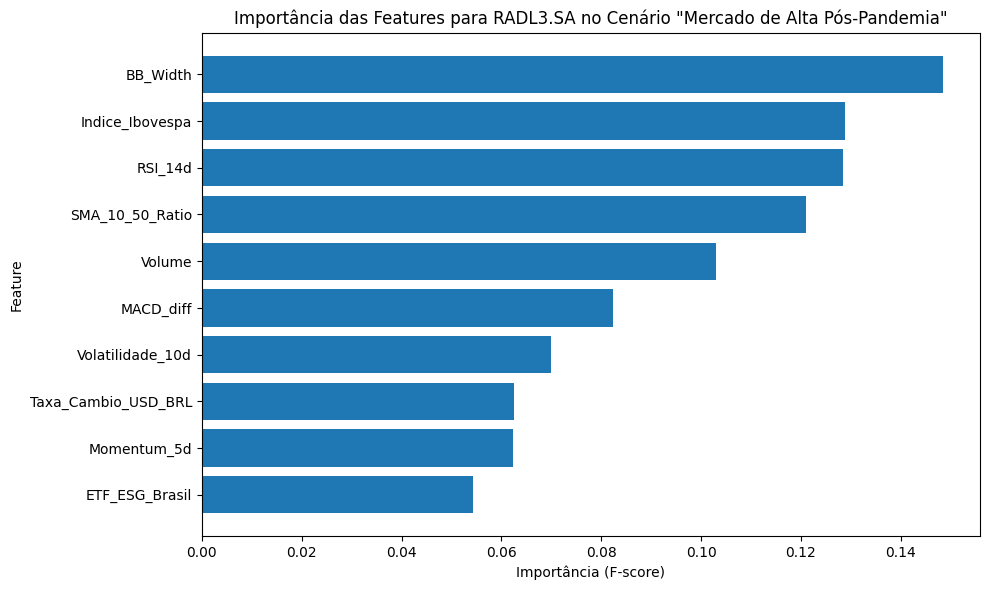

--- Otimizando o limiar de decisão... ---
Melhor limiar encontrado: 0.57
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: RADL3.SA | Cenário: Mercado de Alta Pós-Pandemia
Custo por transação simulado: 0.10%
Período de Teste: 2021-07-01 a 2021-12-29
Lucro/Perda da Estratégia IA: R$ 138.93
Lucro/Perda do Benchmark (Buy & Hold): R$ -5.12
----------------------------------------

Gráfico salvo como 'resultado_RADL3.SA_Mercado_de_Alta_Pós-Pandemia.png'


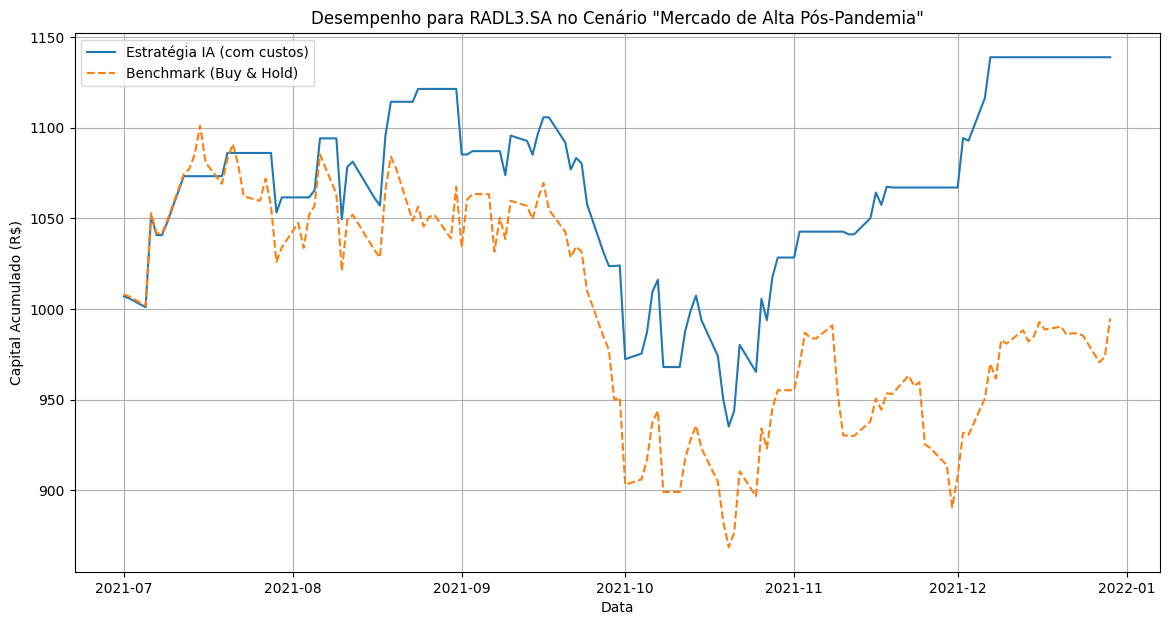


 EXECUTANDO CENÁRIO: 'Mercado Desafiador (Juros Altos)' PARA O ATIVO: VALE3.SA =
--- Coletando dados para VALE3.SA de 2020-01-01 a 2022-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost... ---
Iniciando GridSearchCV com 108 combinações. Isso pode demorar...
Melhores parâmetros encontrados: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}


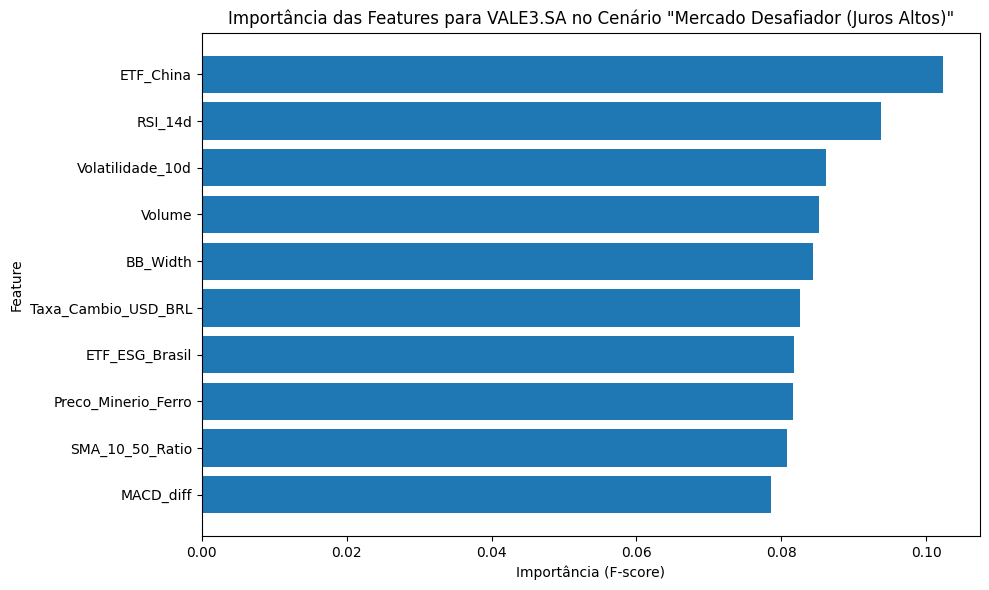

--- Otimizando o limiar de decisão... ---
Melhor limiar encontrado: 0.45
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: VALE3.SA | Cenário: Mercado Desafiador (Juros Altos)
Custo por transação simulado: 0.10%
Período de Teste: 2022-07-01 a 2022-12-29
Lucro/Perda da Estratégia IA: R$ 212.63
Lucro/Perda do Benchmark (Buy & Hold): R$ 249.07
----------------------------------------

Gráfico salvo como 'resultado_VALE3.SA_Mercado_Desafiador_(Juros_Altos).png'


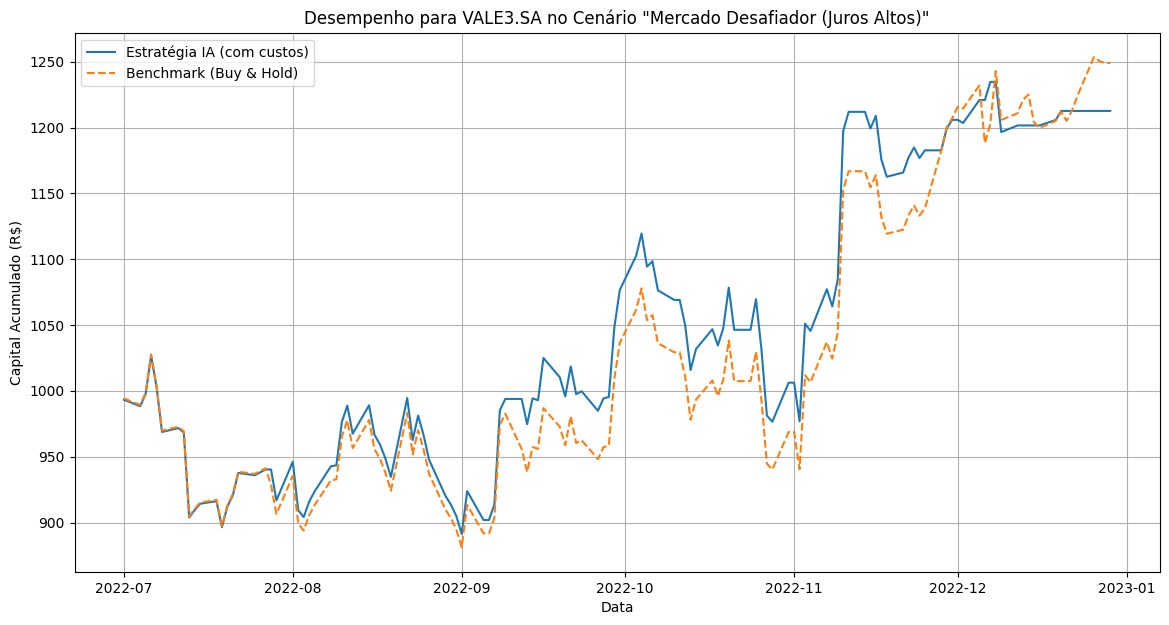


 EXECUTANDO CENÁRIO: 'Mercado Desafiador (Juros Altos)' PARA O ATIVO: ITUB4.SA =
--- Coletando dados para ITUB4.SA de 2020-01-01 a 2022-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost... ---
Iniciando GridSearchCV com 108 combinações. Isso pode demorar...
Melhores parâmetros encontrados: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


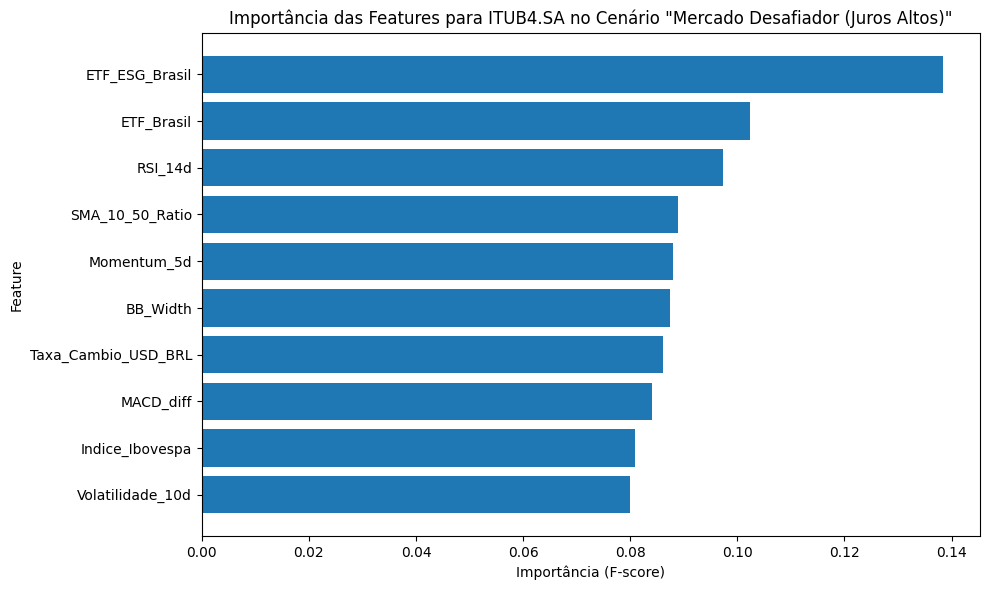

--- Otimizando o limiar de decisão... ---
Melhor limiar encontrado: 0.41
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: ITUB4.SA | Cenário: Mercado Desafiador (Juros Altos)
Custo por transação simulado: 0.10%
Período de Teste: 2022-07-01 a 2022-12-29
Lucro/Perda da Estratégia IA: R$ 276.15
Lucro/Perda do Benchmark (Buy & Hold): R$ 132.18
----------------------------------------

Gráfico salvo como 'resultado_ITUB4.SA_Mercado_Desafiador_(Juros_Altos).png'


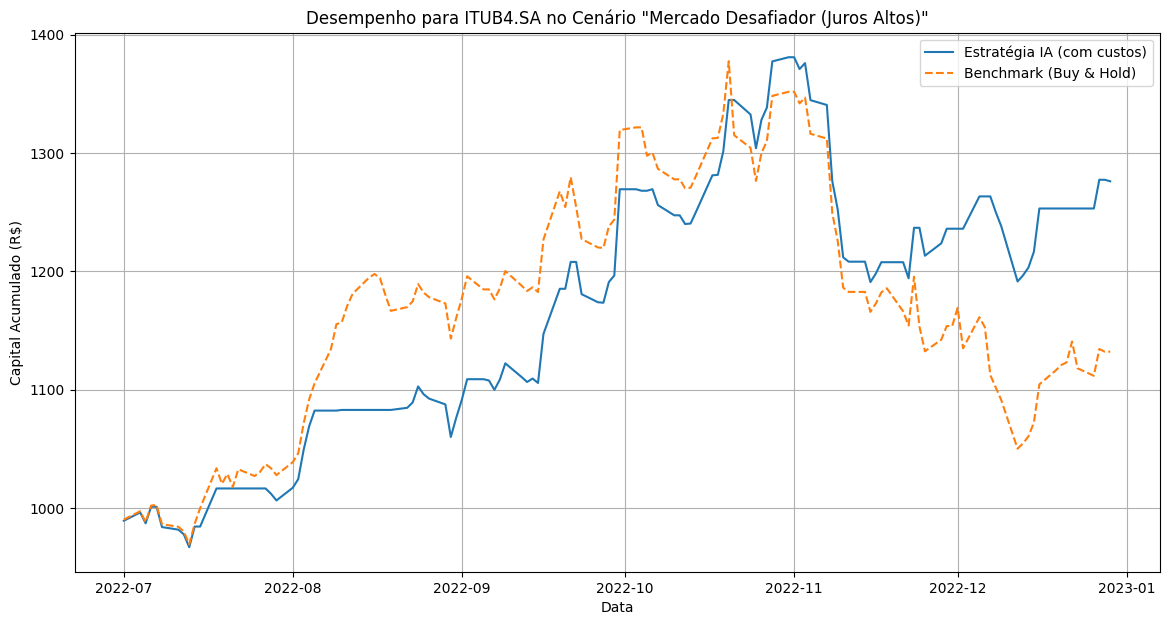


 EXECUTANDO CENÁRIO: 'Mercado Desafiador (Juros Altos)' PARA O ATIVO: LREN3.SA =
--- Coletando dados para LREN3.SA de 2020-01-01 a 2022-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost... ---
Iniciando GridSearchCV com 108 combinações. Isso pode demorar...
Melhores parâmetros encontrados: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}


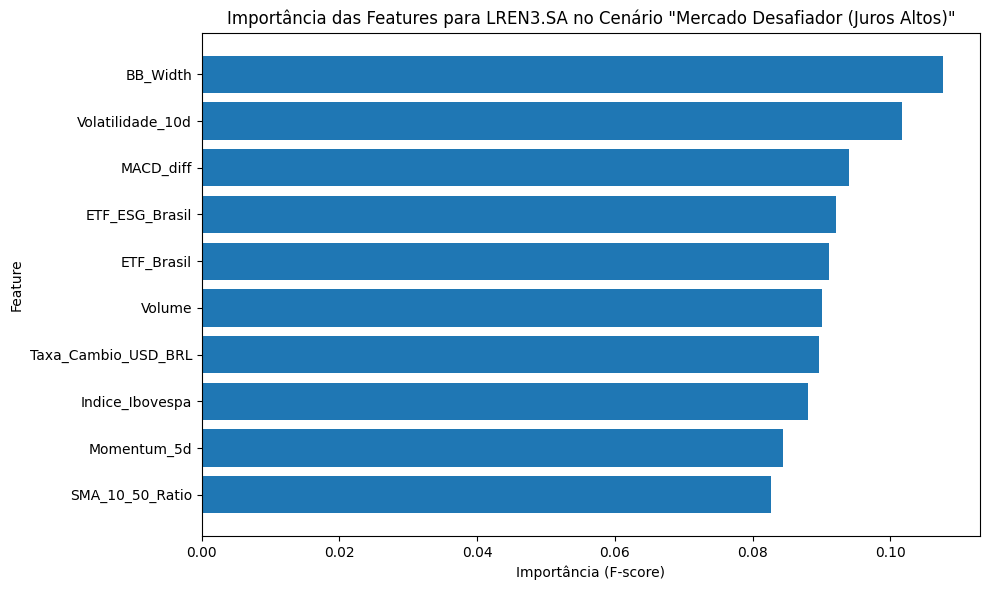

--- Otimizando o limiar de decisão... ---
Melhor limiar encontrado: 0.51
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: LREN3.SA | Cenário: Mercado Desafiador (Juros Altos)
Custo por transação simulado: 0.10%
Período de Teste: 2022-07-01 a 2022-12-29
Lucro/Perda da Estratégia IA: R$ 173.24
Lucro/Perda do Benchmark (Buy & Hold): R$ -99.82
----------------------------------------

Gráfico salvo como 'resultado_LREN3.SA_Mercado_Desafiador_(Juros_Altos).png'


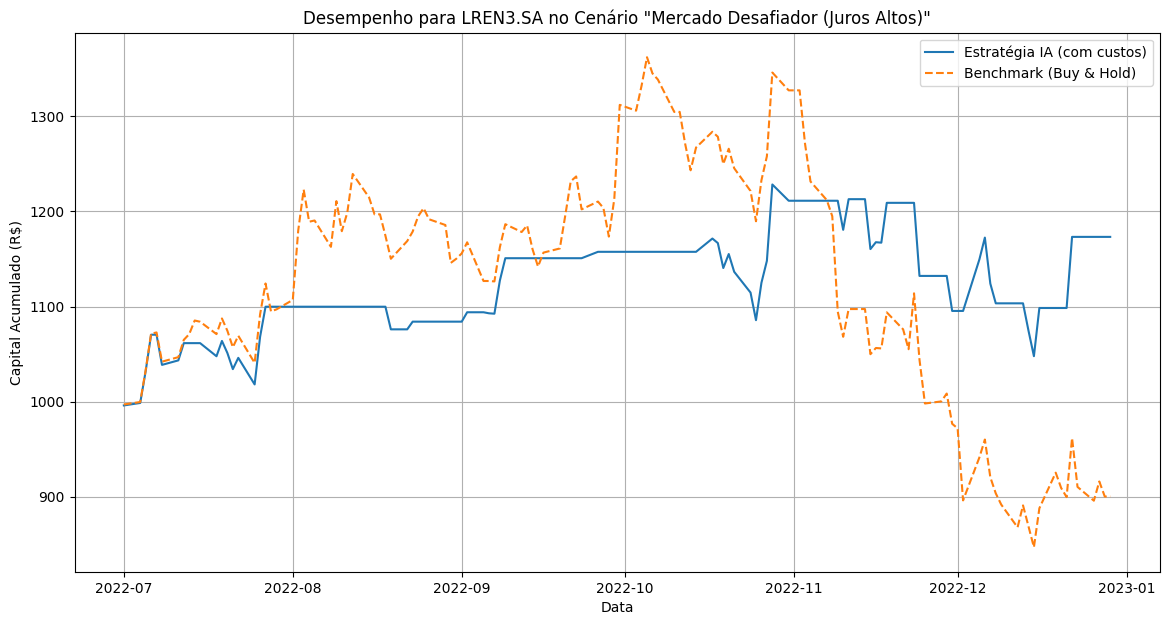


 EXECUTANDO CENÁRIO: 'Mercado Desafiador (Juros Altos)' PARA O ATIVO: ELET3.SA =
--- Coletando dados para ELET3.SA de 2020-01-01 a 2022-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost... ---
Iniciando GridSearchCV com 108 combinações. Isso pode demorar...
Melhores parâmetros encontrados: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


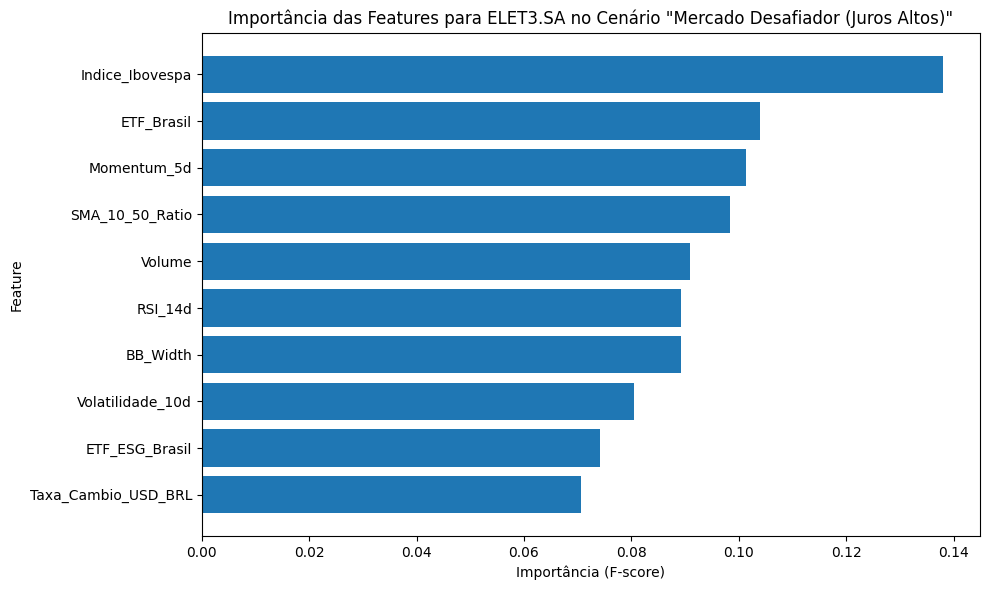

--- Otimizando o limiar de decisão... ---
Melhor limiar encontrado: 0.46
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: ELET3.SA | Cenário: Mercado Desafiador (Juros Altos)
Custo por transação simulado: 0.10%
Período de Teste: 2022-07-01 a 2022-12-29
Lucro/Perda da Estratégia IA: R$ 127.40
Lucro/Perda do Benchmark (Buy & Hold): R$ -81.35
----------------------------------------

Gráfico salvo como 'resultado_ELET3.SA_Mercado_Desafiador_(Juros_Altos).png'


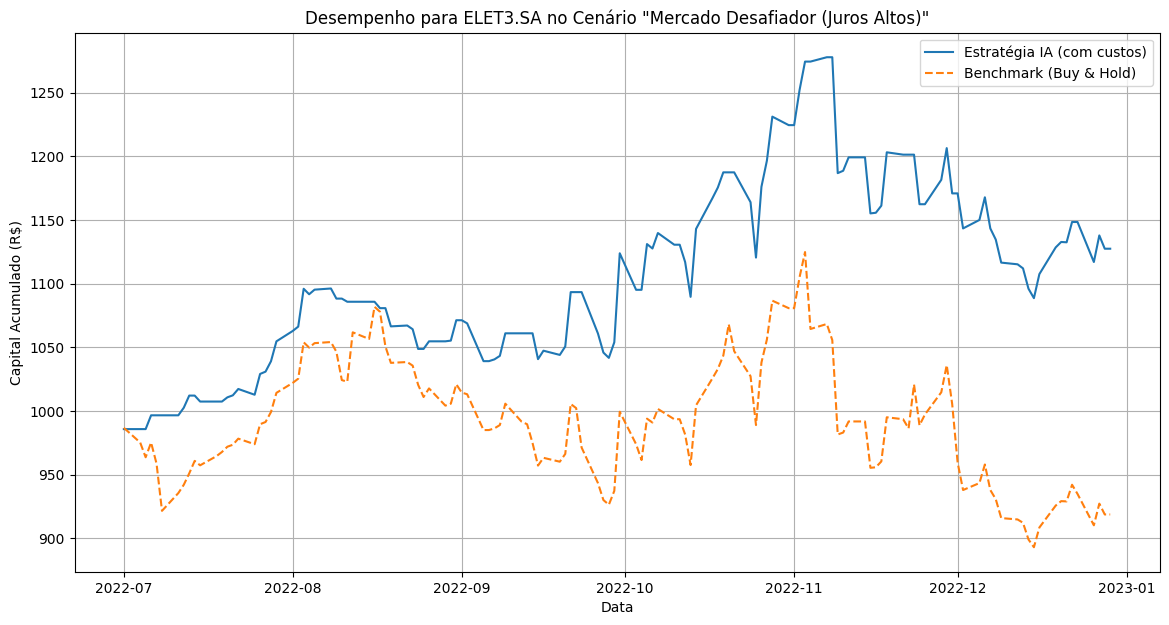


 EXECUTANDO CENÁRIO: 'Mercado Desafiador (Juros Altos)' PARA O ATIVO: RADL3.SA =
--- Coletando dados para RADL3.SA de 2020-01-01 a 2022-12-31 ---
--- Realizando engenharia de fatores ---
--- Otimizando hiperparâmetros do XGBoost... ---
Iniciando GridSearchCV com 108 combinações. Isso pode demorar...
Melhores parâmetros encontrados: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


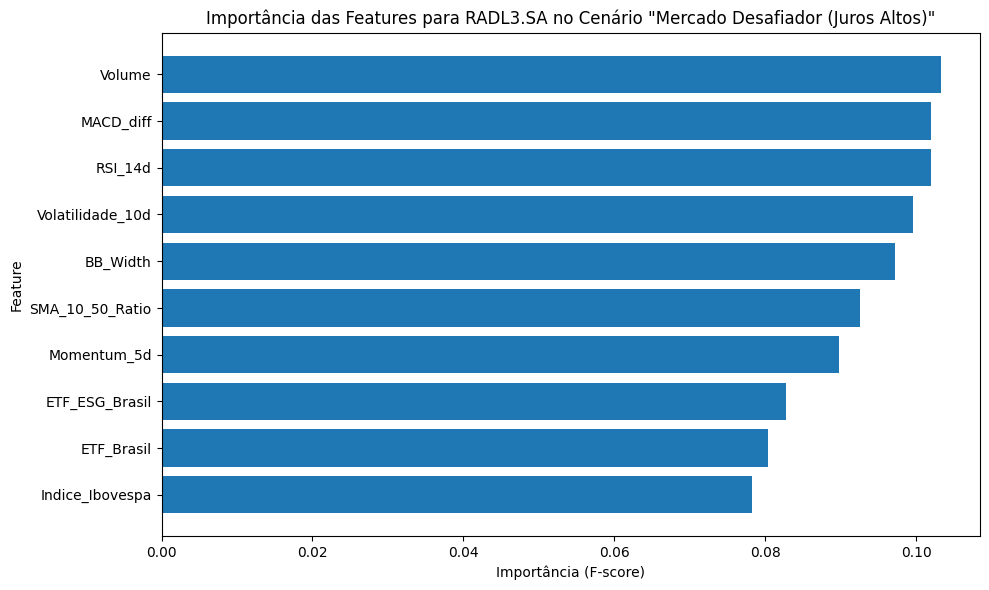

--- Otimizando o limiar de decisão... ---
Melhor limiar encontrado: 0.54
--- Executando backtest final ---

----------------------------------------
RESULTADO FINANCEIRO: RADL3.SA | Cenário: Mercado Desafiador (Juros Altos)
Custo por transação simulado: 0.10%
Período de Teste: 2022-07-01 a 2022-12-29
Lucro/Perda da Estratégia IA: R$ 213.55
Lucro/Perda do Benchmark (Buy & Hold): R$ 263.00
----------------------------------------

Gráfico salvo como 'resultado_RADL3.SA_Mercado_Desafiador_(Juros_Altos).png'


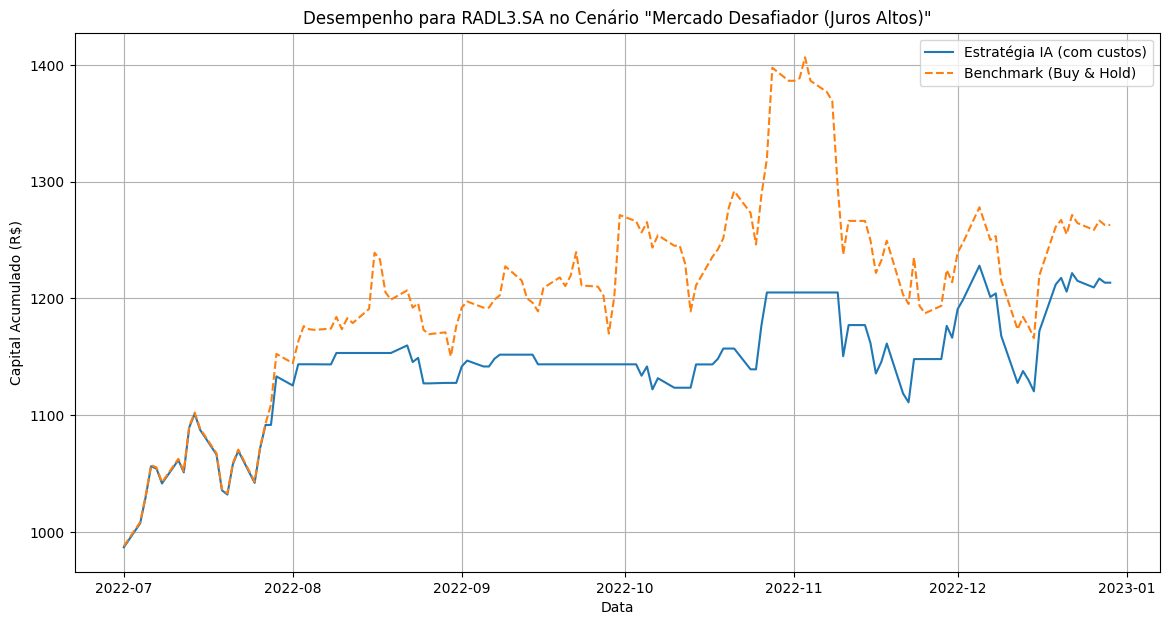

In [4]:
# DESCRIÇÃO: Esta é a célula principal que comanda todo o fluxo de trabalho.
# Ela funciona como um "maestro" que chama cada "operário" (as funções da Célula 3)
# na ordem correta. Ela vai iterar sobre cada cenário e cada ativo que definimos
# no Painel de Controle (Célula 2) e executará o processo completo de
# coleta, engenharia, treino, otimização e teste para cada um deles.

# Cria um dicionário vazio que irá armazenar os resultados finais de cada backtest.
# Usaremos esses resultados nas células seguintes para a análise de métricas e
# a simulação do portfólio consolidado.
resultados_dos_testes = {}
# Define o nome da nossa coluna alvo para ser usado em várias funções.
target = 'Target_Compra'

# --- O Grande Loop de Execução ---
# O primeiro loop passa por cada cenário (ex: "Mercado Desafiador") que definimos.
for cenario_nome, datas in CENARIOS_DE_TESTE.items():
    # O segundo loop passa por cada ativo (ex: "VALE3.SA") dentro do cenário atual.
    for ativo in LISTA_DE_ATIVOS:
        # Imprime cabeçalhos para sabermos qual teste está rodando no momento.
        print("\n" + "="*80)
        print(f" EXECUTANDO CENÁRIO: '{cenario_nome}' PARA O ATIVO: {ativo} ".center(80, "="))
        print("="*80)

        # Pega a configuração do modelo especialista para o ativo atual, definida na Célula 2.
        config = CONFIGURACAO_ESPECIALIZADA_ATIVOS[ativo]
        
        # Passo 1: Chama a função para coletar os dados brutos.
        dados_brutos = coletar_dados(ativo, config['fatores'], config['nomes'], datas['data_inicio_geral'], datas['data_fim_teste'])
        
        # Se a coleta de dados falhar (ex: sem internet), pula para o próximo ativo.
        if dados_brutos.empty:
            print(f"Análise para {ativo} no cenário '{cenario_nome}' cancelada devido à falha na coleta de dados.")
            continue

        # Passo 2: Chama a função para criar os indicadores técnicos (features).
        df_com_features = engenharia_fatores(dados_brutos)

        # Se a engenharia de fatores resultar em uma tabela vazia, pula para o próximo.
        if df_com_features.empty:
            print(f"Análise para {ativo} no cenário '{cenario_nome}' cancelada devido à falha na engenharia de fatores.")
            continue

        # Passo 3: Divide os dados em três períodos cronológicos (passado, presente, futuro).
        # Esta é a etapa crucial para garantir um backtest metodologicamente correto.
        df_treino_raw = df_com_features.loc[:datas['data_fim_treino']]        # Dados para o modelo aprender.
        df_validacao_raw = df_com_features.loc[datas['data_fim_treino'] + timedelta(days=1) : datas['data_fim_validacao']] # Dados para ajustar a estratégia.
        df_teste_raw = df_com_features.loc[datas['data_fim_validacao'] + timedelta(days=1):]      # Dados "nunca vistos" para a prova final.
        
        # Passo 4: Cria a variável alvo ('Target_Compra') de forma segura, APÓS a divisão dos dados.
        # Isso previne o "vazamento de dados do futuro" (lookahead bias).
        df_treino = criar_alvo_e_retorno_futuro(df_treino_raw.copy())
        df_validacao = criar_alvo_e_retorno_futuro(df_validacao_raw.copy())
        df_teste = criar_alvo_e_retorno_futuro(df_teste_raw.copy())

        # Validação para garantir que temos dados suficientes em todos os três períodos.
        if any(df.empty for df in [df_treino, df_validacao, df_teste]):
            print(f"Análise para {ativo} no cenário '{cenario_nome}' cancelada. Dataframes insuficientes após criação do alvo.")
            continue
            
        # Passo 5: Monta a lista final de features que o modelo irá usar.
        # Combina os indicadores técnicos base, os fatores externos (Ibovespa, ESG, etc.)
        # e os novos indicadores técnicos que adicionamos.
        features_base = ['Momentum_5d', 'Volatilidade_10d', 'RSI_14d', 'SMA_10_50_Ratio', 'Volume']
        features_novas = ['MACD_diff', 'BB_Width']
        features = features_base + config['nomes'] + features_novas
        
        # Passo 6: Chama a função para treinar o modelo de IA e encontrar os melhores parâmetros.
        # Passamos o ticker e o cenário para que o gráfico de importância de features seja nomeado corretamente.
        modelo, scaler = otimizar_modelo_xgb(df_treino, features, target, ativo, cenario_nome)
        
        # Se o treino do modelo foi bem-sucedido...
        if modelo:
            # Passo 7: Chama a função para encontrar o melhor "gatilho" de compra (limiar).
            melhor_limiar = otimizar_limiar(modelo, scaler, df_validacao, features)
            
            # Passo 8: Executa a simulação final (backtest) nos dados de teste.
            df_resultado_final = executar_backtest(modelo, scaler, df_teste.copy(), features, melhor_limiar, ativo, cenario_nome, CUSTO_TRANSACAO_PCT)
            
            # Se o backtest foi bem-sucedido, armazena o dataframe com os resultados.
            if df_resultado_final is not None:
                chave_resultado = f"{ativo}_{cenario_nome}"
                # Guardamos o resultado no nosso "grande baú" para usar nas próximas células.
                resultados_dos_testes[chave_resultado] = (df_resultado_final, target)

# CÉLULA 5: ANÁLISE DE MÉTRICAS DE PERFORMANCE DO MODELO

In [5]:
# DESCRIÇÃO: Enquanto as próximas células focarão no resultado FINANCEIRO (lucro/perda),
# esta célula foca na performance PREDITIVA do modelo. O objetivo aqui é
# avaliar o quão bom o nosso modelo de IA é em sua tarefa fundamental: classificar
# corretamente os dias futuros como "Compra" (alta) ou "Não Compra" (baixa).
# Isso nos ajuda a entender a qualidade intrínseca do modelo, separadamente
# de sua performance financeira, que pode ser influenciada pela volatilidade do mercado.

# --- Verificação de Segurança ---
# Primeiro, o código verifica se a Célula 4 foi executada e se gerou algum resultado.
# 'locals()' é uma função Python que verifica todas as variáveis locais existentes.
# Se a variável 'resultados_dos_testes' não existir ou estiver vazia, ele imprime um aviso.
if 'resultados_dos_testes' not in locals() or not resultados_dos_testes:
    print("Nenhum resultado de teste para analisar. Execute a Célula 4 primeiro.")
else:
    # --- Loop de Análise ---
    # Se houver resultados, o código itera sobre cada um deles.
    # 'chave' é o identificador único do teste (ex: "VALE3.SA_Mercado Desafiador (Juros Altos)").
    # 'df_resultado' é a tabela (DataFrame) contendo os sinais e retornos daquele teste.
    for chave, (df_resultado, target_nome) in resultados_dos_testes.items():
        # Extrai o nome do ativo e do cenário a partir da 'chave' para usar nos cabeçalhos.
        partes = chave.split('_', 1)
        ativo = partes[0]
        cenario = partes[1].replace('_', ' ')
        
        # Imprime um cabeçalho para organizar a saída dos resultados.
        print("\n" + "="*80)
        print(f" AVALIANDO MÉTRICAS PARA: {ativo} | CENÁRIO: {cenario} ".center(80, "="))
        print("="*80)
        
        # Chama a função 'avaliar_performance_modelo' (definida na Célula 3)
        # para fazer o trabalho pesado de calcular e imprimir o relatório de classificação.
        avaliar_performance_modelo(df_resultado, target_nome)


== AVALIANDO MÉTRICAS PARA: VALE3.SA | CENÁRIO: Mercado de Alta Pós-Pandemia ===

----------------------------------------
MÉTRICAS DE CLASSIFICAÇÃO
                precision    recall  f1-score   support

Não Compra (0)       0.67      0.05      0.09        81
    Compra (1)       0.38      0.96      0.54        49

      accuracy                           0.39       130
     macro avg       0.52      0.50      0.32       130
  weighted avg       0.56      0.39      0.26       130

----------------------------------------

== AVALIANDO MÉTRICAS PARA: ITUB4.SA | CENÁRIO: Mercado de Alta Pós-Pandemia ===

----------------------------------------
MÉTRICAS DE CLASSIFICAÇÃO
                precision    recall  f1-score   support

Não Compra (0)       0.63      0.77      0.69        78
    Compra (1)       0.49      0.33      0.39        52

      accuracy                           0.59       130
     macro avg       0.56      0.55      0.54       130
  weighted avg       0.57      0.59   

# CÉLULA 6: SIMULAÇÃO DO PORTFÓLIO CONSOLIDADO


 GERANDO ANÁLISE FINAL COMPLETA PARA O CENÁRIO: 'Mercado de Alta Pós-Pandemia' =

--- RESULTADO FINANCEIRO FINAL COMPARATIVO ---
Cenário: Mercado de Alta Pós-Pandemia

Estratégia/Benchmark                     |     Lucro/Perda (R$)
-----------------------------------------------------------------
Benchmark (ETF ESG Passivo)              |             -1444.03
Benchmark (Ibovespa)                     |             -1655.34
🏆 IA Ponderada pela Confiança            |             -1787.47
Benchmark (Buy & Hold dos Ativos)        |             -2103.50
-----------------------------------------------------------------


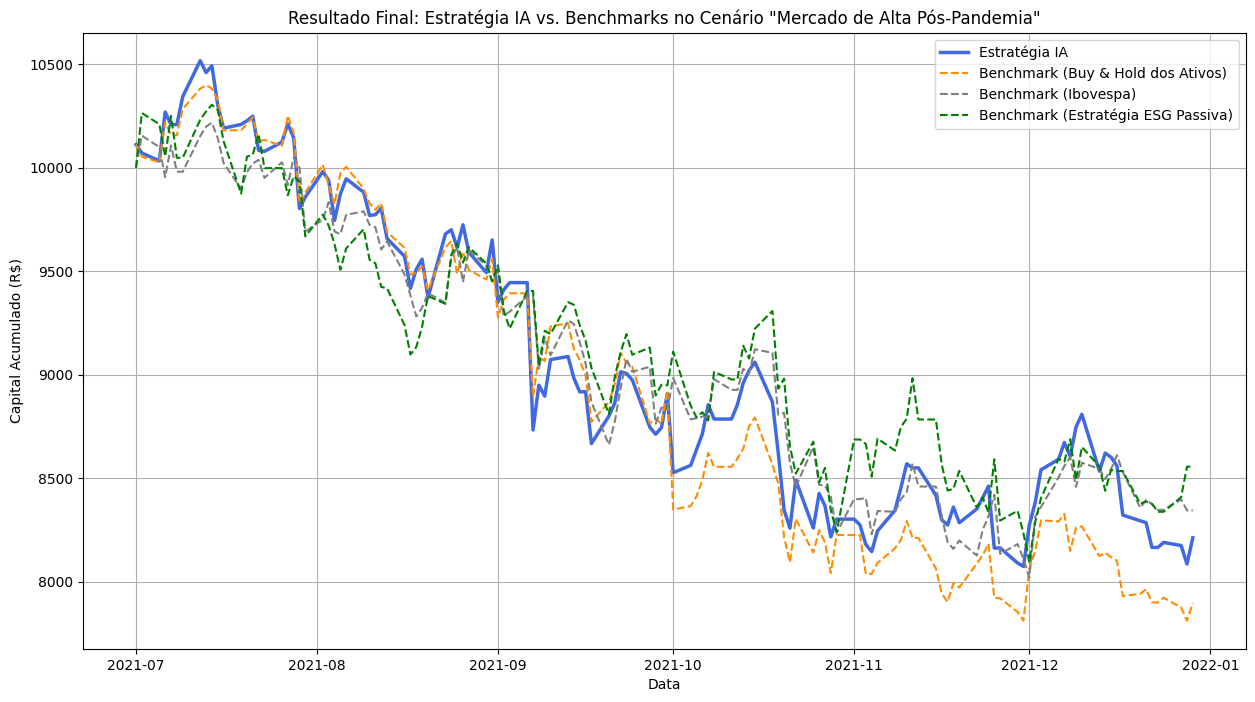


 GERANDO ANÁLISE FINAL COMPLETA PARA O CENÁRIO: 'Mercado Desafiador (Juros Altos)' 

--- RESULTADO FINANCEIRO FINAL COMPARATIVO ---
Cenário: Mercado Desafiador (Juros Altos)

Estratégia/Benchmark                     |     Lucro/Perda (R$)
-----------------------------------------------------------------
🏆 IA Ponderada pela Confiança            |              2291.87
Benchmark (Buy & Hold dos Ativos)        |              1207.87
Benchmark (Ibovespa)                     |              1140.23
Benchmark (ETF ESG Passivo)              |               -47.87
-----------------------------------------------------------------


C:\Users\jgsei\AppData\Local\Temp\ipykernel_26220\197037677.py:44: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_portfolio['Retorno_ESG_ETF'] = benchmarks_data['Close']['ESGB11.SA'].pct_change()


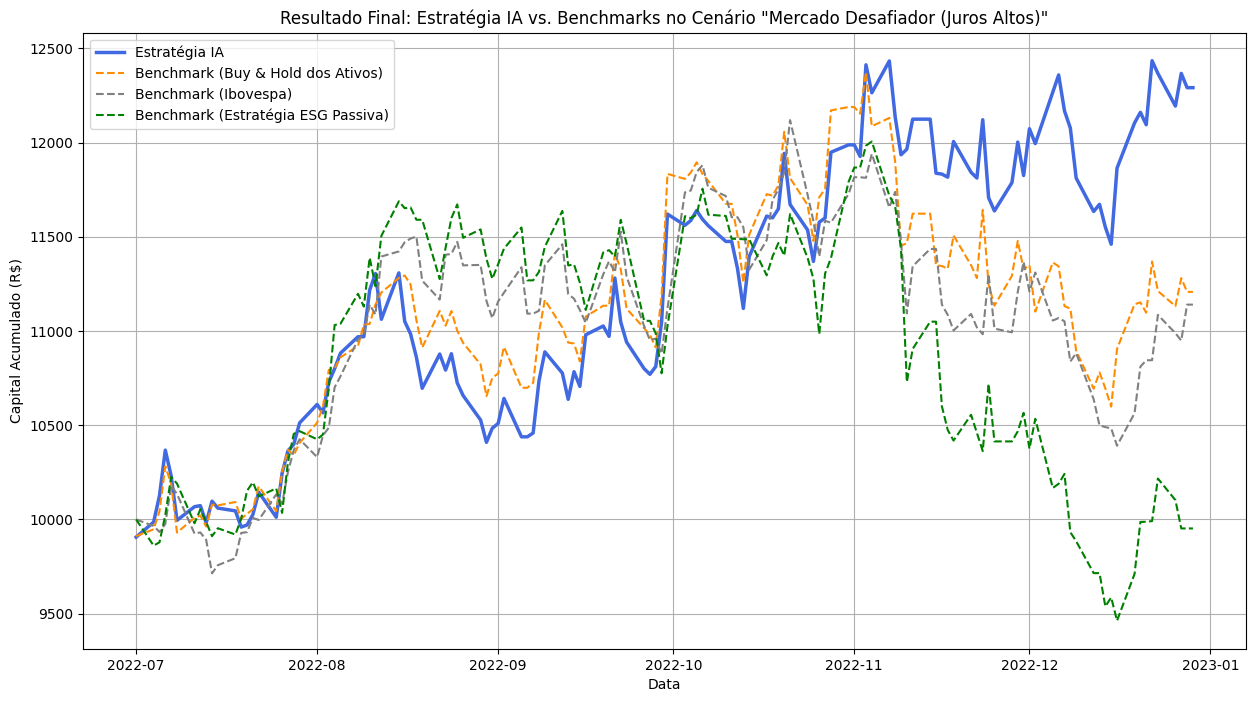

In [9]:
# DESCRIÇÃO: Esta é a célula conclusiva do projeto. Ela simula o desempenho
# da nossa carteira de investimentos gerenciada pela IA e a compara contra
# todos os benchmarks relevantes para provar o valor da nossa estratégia.
# O gráfico final contará a história completa, respondendo às perguntas-chave:
# 1. A nossa IA foi melhor que uma estratégia passiva com os mesmos ativos? (Benchmark de Ativos)
# 2. A nossa IA superou o mercado brasileiro em geral? (Ibovespa)
# 3. A nossa abordagem ATIVA de ESG foi superior a uma abordagem PASSIVA? (ETF ESG)

def gerar_analise_final_completa(resultados, cenario_alvo, capital_inicial=10000):
    """
    Simula e compara as estratégias de IA (Peso Igual e Ponderada) contra
    os três benchmarks essenciais: Média dos Ativos, Ibovespa e ETF ESG.
    """
    print("\n" + "="*80)
    print(f" GERANDO ANÁLISE FINAL COMPLETA PARA O CENÁRIO: '{cenario_alvo}' ".center(80, "="))
    print("="*80)

    # Passo 1: Coleta e organiza os dados dos modelos da IA.
    dfs_cenario = []
    for chave, (df_resultado, _) in resultados.items():
        if cenario_alvo in chave:
            ativo = chave.split('_')[0]
            # Seleciona as colunas que precisamos: Retorno, Sinal e a Probabilidade (confiança).
            df_temp = df_resultado[['Retorno_Futuro', 'Sinal_IA', 'Probabilidade_IA']].rename(columns={
                'Retorno_Futuro': f'Retorno_{ativo}',
                'Sinal_IA': f'Sinal_{ativo}',
                'Probabilidade_IA': f'Prob_{ativo}'
            })
            dfs_cenario.append(df_temp)
    
    if not dfs_cenario:
        print(f"Nenhum resultado encontrado para o cenário '{cenario_alvo}'.")
        return

    df_portfolio = pd.concat(dfs_cenario, axis=1).ffill()
    
    # Passo 2: Busca os dados para os benchmarks externos (IBOV e ESG).
    data_inicio_teste = df_portfolio.index.min()
    data_fim_teste = df_portfolio.index.max()
    
    try:
        benchmarks_data = yf.download(['^BVSP', 'ESGB11.SA'], start=data_inicio_teste, end=data_fim_teste, progress=False, auto_adjust=True)
        df_portfolio['Retorno_Ibov'] = benchmarks_data['Close']['^BVSP'].pct_change()
        df_portfolio['Retorno_ESG_ETF'] = benchmarks_data['Close']['ESGB11.SA'].pct_change()
    except Exception as e:
        print(f"Aviso: Não foi possível baixar os dados dos benchmarks externos: {e}")
        df_portfolio['Retorno_Ibov'] = 0
        df_portfolio['Retorno_ESG_ETF'] = 0

    # Passo 3: Simulação das estratégias e benchmarks.
    df_portfolio['Retorno_Ponderado_Confianca'] = 0.0
    sinais_cols = [col for col in df_portfolio.columns if 'Sinal_' in col]
    retorno_cols = [col for col in df_portfolio.columns if 'Retorno_' in col and 'Portfolio' not in col and 'Ibov' not in col and 'ETF' not in col]

    # Lógica de cálculo das estratégias da IA.
    for index, row in df_portfolio.iterrows():
        sinais_ativos = row[sinais_cols]
        ativos_comprados = sinais_ativos[sinais_ativos == 1]
        num_ativos_comprados = len(ativos_comprados)
        
        if num_ativos_comprados > 0:
            # Estratégia 1: Peso Igual
            peso_igual = 1.0 / num_ativos_comprados
            retorno_dia_igual = 0
            
            # Estratégia 2: Ponderado pela Confiança
            soma_confianca = 0
            for ativo_idx, _ in ativos_comprados.items():
                ativo = ativo_idx.split('_')[1]
                soma_confianca += row.get(f'Prob_{ativo}', 0)
            retorno_dia_ponderado = 0
            
            for ativo_idx, _ in ativos_comprados.items():
                ativo = ativo_idx.split('_')[1]
                retorno_ativo = row.get(f'Retorno_{ativo}', 0)
                # Cálculo para Peso Igual
                retorno_dia_igual += retorno_ativo * peso_igual
                # Cálculo para Ponderado pela Confiança
                confianca_ativo = row.get(f'Prob_{ativo}', 0)
                peso_ponderado = confianca_ativo / soma_confianca if soma_confianca > 0 else 0
                retorno_dia_ponderado += retorno_ativo * peso_ponderado
                
            df_portfolio.loc[index, 'Retorno_Ponderado_Confianca'] = retorno_dia_ponderado

    # Passo 4: Cálculo de todas as curvas de capital.
    df_portfolio['Capital_Ponderado_Confianca'] = capital_inicial * (1 + df_portfolio['Retorno_Ponderado_Confianca']).cumprod()
    df_portfolio['Retorno_Benchmark_Portfolio'] = df_portfolio[retorno_cols].mean(axis=1)
    df_portfolio['Capital_Benchmark_Portfolio'] = capital_inicial * (1 + df_portfolio['Retorno_Benchmark_Portfolio']).cumprod()
    df_portfolio['Capital_Ibov'] = capital_inicial * (1 + df_portfolio['Retorno_Ibov'].fillna(0)).cumprod()
    df_portfolio['Capital_ESG_ETF'] = capital_inicial * (1 + df_portfolio['Retorno_ESG_ETF'].fillna(0)).cumprod()

    # Passo 5: Apresentação da tabela de resultados finais, ordenada pelo melhor desempenho.
    print("\n--- RESULTADO FINANCEIRO FINAL COMPARATIVO ---")
    print(f"Cenário: {cenario_alvo}\n")
    print(f"{'Estratégia/Benchmark':<40} | {'Lucro/Perda (R$)':>20}")
    print("-" * 65)
    resultados_finais = {
        '🏆 IA Ponderada pela Confiança': df_portfolio['Capital_Ponderado_Confianca'].iloc[-1] - capital_inicial,
        'Benchmark (Buy & Hold dos Ativos)': df_portfolio['Capital_Benchmark_Portfolio'].iloc[-1] - capital_inicial,
        'Benchmark (Ibovespa)': df_portfolio['Capital_Ibov'].iloc[-1] - capital_inicial,
        'Benchmark (ETF ESG Passivo)': df_portfolio['Capital_ESG_ETF'].iloc[-1] - capital_inicial,
    }
    for nome, valor in sorted(resultados_finais.items(), key=lambda item: item[1], reverse=True):
        print(f"{nome:<40} | {valor:>20.2f}")
    print("-" * 65)

    # Passo 6: Plotagem do gráfico final com todas as 4 linhas de comparação essenciais.
    plt.figure(figsize=(15, 8))
    plt.plot(df_portfolio.index, df_portfolio['Capital_Ponderado_Confianca'], label='Estratégia IA', linewidth=2.5, color='royalblue')
    plt.plot(df_portfolio.index, df_portfolio['Capital_Benchmark_Portfolio'], label='Benchmark (Buy & Hold dos Ativos)', linestyle='--', color='darkorange')
    plt.plot(df_portfolio.index, df_portfolio['Capital_Ibov'], label='Benchmark (Ibovespa)', linestyle='--', color='gray')
    plt.plot(df_portfolio.index, df_portfolio['Capital_ESG_ETF'], label='Benchmark (Estratégia ESG Passiva)', linestyle='--', color='green')
    
    plt.title(f'Resultado Final: Estratégia IA vs. Benchmarks no Cenário "{cenario_alvo}"')
    plt.xlabel('Data')
    plt.ylabel('Capital Acumulado (R$)')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Execução da Análise Final ---
if 'resultados_dos_testes' in locals() and resultados_dos_testes:
    for cenario in CENARIOS_DE_TESTE.keys():
        gerar_analise_final_completa(resultados_dos_testes, cenario)
else:
    print("\nExecute as células anteriores para gerar os resultados individuais primeiro.")